In [92]:
import pandas as pd
import numpy as np

#graphs 
import seaborn as sns
import matplotlib.pyplot as plt 

#stats 
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller

#decomposicao de time-series 

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#teste de tendencia
from pymannkendall import original_test

#timeseries 

from mlforecast import MLForecast

#media movel 

from mlforecast.lag_transforms import RollingMean, RollingMax, SeasonalRollingMean

#regressao linear 

import statsmodels.api as sm
from statsmodels.tsa.deterministic import DeterministicProcess

#modelos de regressao 
from sklearn.linear_model import LinearRegression

#divisao treino e test 

from sklearn.model_selection import train_test_split

#features selection
from sklearn.feature_selection import mutual_info_regression


#datetime 

import datetime

# Funções

In [3]:
class EdaTimeSeries():
    def __init__(self, ts: pd.DataFrame):
        self.ts = ts
    def univariate_hist_box(self):
        fig, axs = plt.subplots(2,2, figsize=(12,8))
        axs = axs.flatten()
        
        u = self.ts['y'].mean()
        md = self.ts['y'].median()
        
        sns.histplot(data=self.ts, x='y', ax=axs[0])
        axs[0].set_title('Histograma da Receita Diária')
        axs[0].axvline(x=u, color='dimgray', linestyle="--", label='media')
        axs[0].axvline(x=md, color='black', linestyle="--", label='mediana')
        axs[0].legend()
        
        sns.kdeplot(data=self.ts, x='y', ax=axs[1])
        axs[1].set_title('Densidade')
        axs[1].axvline(x=u, color='dimgray', linestyle="--", label='media')
        axs[1].axvline(x=md, color='black', linestyle="--", label='mediana')
        axs[1].legend()
        
        sns.boxplot(data=self.ts, x='y', ax=axs[2])
        axs[2].set_title('Boxplot')
        
        sns.scatterplot(data=self.ts, x=self.ts.index, y='y', ax=axs[3])
        axs[3].set_title('Dispersao')
        
        fig.tight_layout()
        plt.show()
    
    def line_over_period(self, period, hue=None):
        fig, ax = plt.subplots(figsize=(10,4))
        if hue is None: 
            sns.lineplot(data=self.ts, x=period, y='y', ax=ax)
        else: 
            sns.lineplot(data=self.ts, x=period, y='y', hue=hue, ax=ax)
        ax.set_title(f'Receita por {period}')
        ax.set_xlabel(f'{period}')
        ax.set_xticks(ax.get_xticks()[::3])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
        plt.tight_layout()
        plt.show()
    
    def plot_acf_pacf(self):
        fix, axs = plt.subplots(1,2, figsize=(12,4))
        axs = axs.flatten()
        
        plot_acf(self.ts['y'], ax=axs[0], title="ACF")
        plot_pacf(self.ts['y'], ax=axs[1], title="PACF")
        
    def decomposition_time_series(self, model='additive', period=12):
        y_dec = self.ts[["ds", "y"]]
        y_dec = y_dec.set_index("ds")
        result = seasonal_decompose(y_dec["y"], model=model, period=period)
        return result

    def trend_graph(self, order=1):
        y = self.ts.loc[:, ['ds', 'y']]
        y.set_index('ds', inplace=True)
        
        dp = DeterministicProcess(
            index=y.index,
            constant=True,
            order=order,
            drop=True
        )
        X = dp.in_sample()
        linear_regression = LinearRegression(fit_intercept=False)
        linear_regression.fit(X, y)
        
        y_fit = pd.DataFrame(
            linear_regression.predict(X),
            index = y.index,
            columns = y.columns
        )
        
        fig, ax = plt.subplots(figsize=(6,4))
        ax.plot(y, color="cornflowerblue", label="Serie Original")
        ax.plot(y_fit, color="darkslategray", label="Trend")
        ax.legend()
        plt.show()
    
    def moving_average_graph(self, len_window, min_periodos):
        moving_average = self.ts["y"].rolling(
            window=len_window,
            center=True,
            min_periods=min_periodos
        ).mean()
        fig, ax = plt.subplots(figsize=(8,4))
        sns.lineplot(x=self.ts["ds"], y=self.ts["y"], color="cornflowerblue", label="Original Series", ax=ax)
        sns.lineplot(x=self.ts["ds"], y=moving_average, color="black", label=f"Moving Average {len_window}", ax=ax)
        ax.legend()
        plt.show()
    
    def line_subplots_period(self, period_principal="month", period_sec="weekday"):
        if period_principal == "month":
            periods = self.ts[period_principal].unique()
            nrows = 3
            ncols = 4
            fig, axs = plt.subplots(nrows, ncols, figsize=(16,7))
            
        elif period_principal == "year":
            periods = self.ts[period_principal].unique()
        
        for i, period in enumerate(periods):
            row = i // ncols
            col = i % ncols
            period_loc = self.ts.loc[self.ts[period_principal] == period, [period_sec, "y"]]
            sns.lineplot(data=period_loc, x=period_sec, y="y", ax=axs[row, col])
            axs[row, col].set_title(f"Período: {period}")
            
        fig.tight_layout()
        plt.show()
    
    def line_over_period(self, period="month", hue=None):
        plt.figure(figsize=(6,4))
        if hue:
            ts_group = self.ts.groupby([hue, period])["y"].sum().reset_index()
            ax = sns.lineplot(data=ts_group, x=period, y="y", hue=hue)
        else: 
            ts_group = self.ts.groupby(period)["y"].sum().reset_index()
            ax = sns.lineplot(data=ts_group, x=period, y="y")
        plt.xlabel(period)
        plt.ylabel("y")
        ax.set_xticks(ax.get_xticks()[::2])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=6)
        plt.tight_layout()
        plt.show()
        
    def box_plot_over_period(self, period="month"):
        plt.figure(figsize=(15,4))
        ax = sns.boxplot(data=self.ts, x=period, y='y')
        ax.set_xticks(ax.get_xticks()[::2])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=6)
        plt.tight_layout()
        plt.show()



In [4]:
class TestStatistical():
    def test_trend_linear_regression(self, data):
        X = np.arange(len(data))
        X = sm.add_constant(X)
        model = sm.OLS(data, X).fit()
        slope = model.params[1]
        print(f'Coeficiente angular: {slope}')
        if abs(slope) > 0:
          print('Possível tendência detectada\n')
        else:
          print('Sem tendência detectada\n')

        print('========================================\n')
        print('Componentes Detalhados Regressão Linear\n')
        print(model.summary())

    def test_normalidade(self, data, alfa=0.05):
        statistic, p_value = stats.shapiro(x=data)
        if p_value > alfa:
          return f"Rejeitamos a hipótese nula com nível de significância: {alfa} e p_value: {p_value}. Ou seja os dados se distribuem normalmente"
        else:
          return f"Aceitamos a hipótese nula com nível de significância: {alfa} e p_value: {p_value}. Ou seja os dados não se distribuem normalmente"
    
    def test_estacionariedade(self, data, nivel_significancia=0.05):
        adf = adfuller(x=data)
        print(f'Estatística do teste ADF: {adf[0]}')
        print(f'P-value: {adf[1]}')
        print(f'Número de Lags Usados: {adf[2]}')
        print(f'Número de Observações Usadas {adf[3]}')
        print(f'Valores Críticos')
        for chave, valor in adf[4].items():
            print(f'{chave}: {valor:.3f}')
        if adf[1] < nivel_significancia:
          print('Série Considerada Estacionária')
        else:
          print('Série Não Estacionária')

    def teste_sazonalidade(self, grupos, alfa=0.05):
        stat, p_value = stats.kruskal(*grupos)
        if p_value > alfa:
          return f"Não rejeitamos a hipóteste nula com p_value de {p_value} com nível de significância: {alfa}. Não há evidências de sazonalidade"
        else:
          return f"Aceitamos a hipótese nula com p_value: {p_value} com nível de significância: {alfa}. Há evidências de sazonalidade"

In [5]:
#funcoes transformacao data 

def year_month(dates):
    return dates.strftime("%Y-%m")

def quarter(dates):
    return ((dates.month - 1) // 3) + 1

In [6]:
def create_list_dates(date_initial, qtd_dias):
    date_initial = pd.to_datetime(date_initial)
    list_dates = [date_initial + datetime.timedelta(days=i) for i in range(qtd_dias)]
    return list_dates 

def create_promo(period_list, promo_name, data):
    promo_true = [True] * len(period_list)
    if not data:
        data[promo_name] = promo_true
        data["ds"] = period_list
    else: 
        data[promo_name].extend(promo_true)
        data["ds"].extend(period_list)
    return data

# Import File

In [7]:
df = pd.read_parquet("data/silver/sales_per_region.parquet")

In [8]:
df.head(3)

,numero_do_pedido,data,status_pagamento,estado,total
0,12309,2025-06-16,Confirmado,São Paulo,101.79
1,12308,2025-06-15,Confirmado,São Paulo,187.26
2,12307,2025-06-15,Confirmado,Paraná,119.01


In [9]:
df = df.loc[df['data'] < "2025-06-01", :].reset_index(drop=True)

# EDA

## Agregação de Dados por Dia

In [10]:
ts = df.groupby("data")["total"].sum().reset_index()
ts.columns = ["ds", "y"]
ts.head(3)

,ds,y
0,2022-04-18,339.75
1,2022-04-19,99.60
2,2022-04-20,58.38


## Criação de Features de Data

In [11]:
ts.insert(0, 'unique_id', 'ecommerce-sale')

preprocess = MLForecast(
    models=[],
    freq=['D'],
    date_features=['day', 'year', 'month', 'weekday', year_month, quarter]
)

ts = preprocess.preprocess(ts)

## Descritiva

In [12]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   unique_id   1128 non-null   object        
 1   ds          1128 non-null   datetime64[ns]
 2   y           1128 non-null   float64       
 3   day         1128 non-null   uint8         
 4   year        1128 non-null   uint16        
 5   month       1128 non-null   uint8         
 6   weekday     1128 non-null   uint8         
 7   year_month  1128 non-null   object        
 8   quarter     1128 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(2), uint16(1), uint8(3)
memory usage: 45.3+ KB


In [13]:
ts[['ds', 'y']].describe().T

,count,mean,min,25%,50%,75%,max,std
ds,1128,2023-11-12 04:47:14.042553344,2022-04-18 00:00:00,2023-02-01 06:00:00,2023-11-14 12:00:00,2024-08-22 06:00:00,2025-05-31 00:00:00,NaN
y,1128.0,1231.022686,20.85,633.1825,1091.21,1655.31,13543.14,901.732035


- Temos um pouco mais do que 3 anos de dados
- Média e mediana, a princípio, não muito distante uma da outra.
- O máximo valor bem acima do nosso percentil 75.

## Analise de Distribuição da Receita

In [14]:
testes = TestStatistical()

In [15]:
eda = EdaTimeSeries(ts=ts)

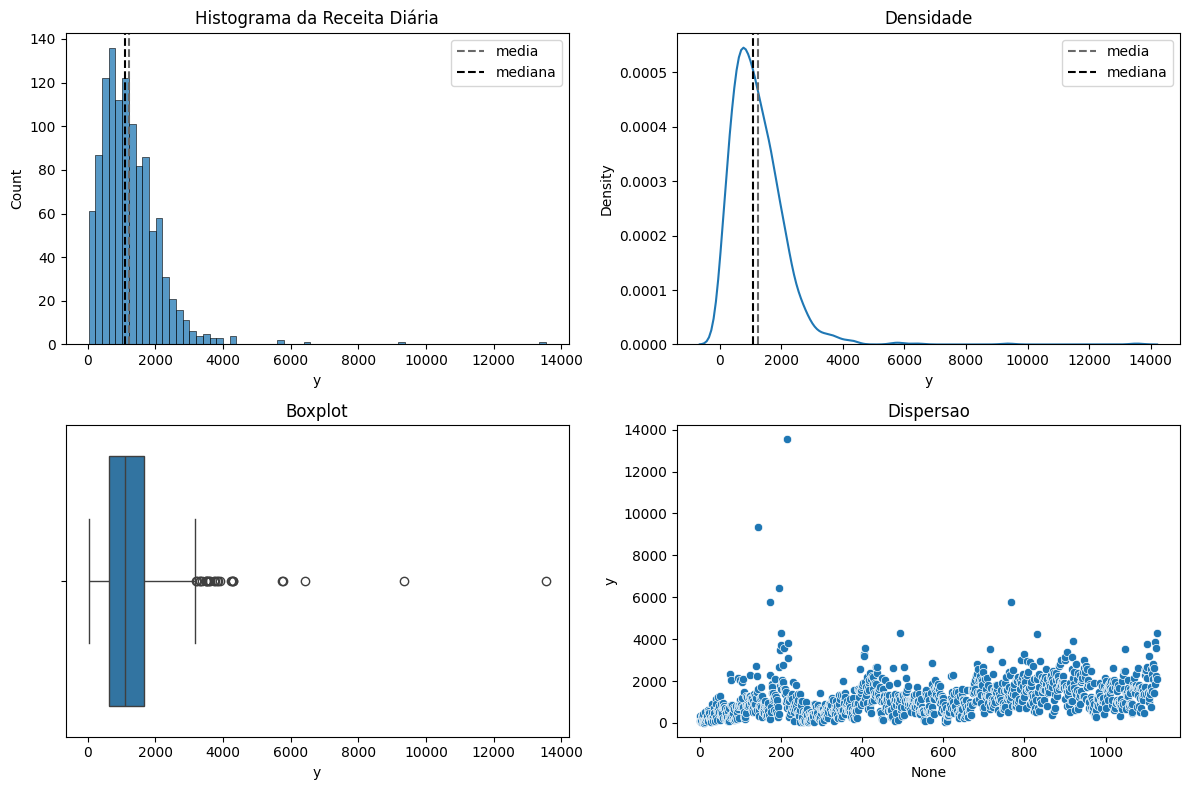

In [16]:
eda.univariate_hist_box()

In [17]:
print(f"Curtose dos dados: {stats.kurtosis(ts['y'])}")
print(f"Assimetria nos dados de: {stats.skew(ts['y'])}")

Curtose dos dados: 37.705574278413096
Assimetria nos dados de: 3.7679845226988857


- Percebe-se que temos alguns outliers que são bem acima, destoando dos demais valores encontrados
- Isso fica evidente no dado de assimetria, que está a direita (positivo). Onde em sua maior parte os dados estão concentrados em valores mais baixos, porém os valores mais altos acaba puxando a distribuição
- Uma transformação nos dados vai ser importante para conseguirmos estabilizar a variância

## Análise de Outliers

- Utilizaremos o método de IQR para identificarmos os outliers e consequentemente validar se existe algum padrão entre eles.

In [18]:
q3 = ts['y'].quantile(.75)
q1 = ts['y'].quantile(.25)
abo = q3 + (1.5*(q3-q1))

ts_outlier = ts.loc[ts['y'] > abo, :]
ts_outlier.head(3)

,unique_id,ds,y,day,year,month,weekday,year_month,quarter
144,ecommerce-sale,2022-09-14,9353.15,14,2022,9,2,2022-09,3
173,ecommerce-sale,2022-10-13,5754.12,13,2022,10,3,2022-10,4
195,ecommerce-sale,2022-11-04,6422.40,4,2022,11,4,2022-11,4


In [19]:
qtd_outlier = len(ts_outlier)
total_data = len(ts)

print(f"Quantidade de outliers: {qtd_outlier}")
print(f"Percentual de outliers: {qtd_outlier/total_data:.2f}")

Quantidade de outliers: 25
Percentual de outliers: 0.02


- Temos um total de 2,00% de outlier em todo nosso dado

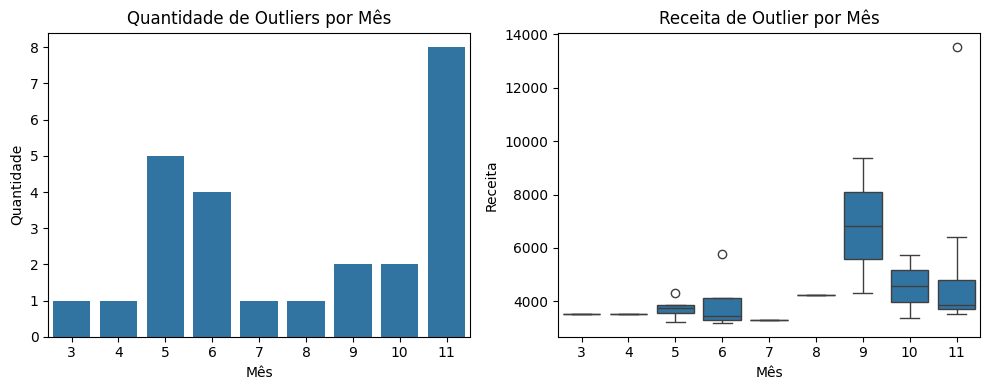

In [20]:
qtd_outlier_mes = ts_outlier['month'].value_counts().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax = ax.flatten()

sns.barplot(data=qtd_outlier_mes, x='month', y='count', ax=ax[0])
ax[0].set_title('Quantidade de Outliers por Mês')
ax[0].set_ylabel('Quantidade')
ax[0].set_xlabel('Mês')

sns.boxplot(data=ts_outlier, x='month', y='y', ax=ax[1])
ax[1].set_title('Receita de Outlier por Mês')
ax[1].set_ylabel('Receita')
ax[1].set_xlabel('Mês')

plt.tight_layout()
plt.show()

- Os outliers em sua maioria acontecem no mês de novembro, BlackFriday, que era de se esperar em um e-commerce.
- Posteriormente, vemos os meses de maio e junho como o segundo em resultado.
- Em questão de distribuição de receita, setembro apresenta uma distribuição maior.
- Além disso, dentro do mês de novembro, que é a black, não apresentou uma distribuição de receita tão grande quanto setembro, mas tem um ponto de máximo bem considerável na casa dos 14k.

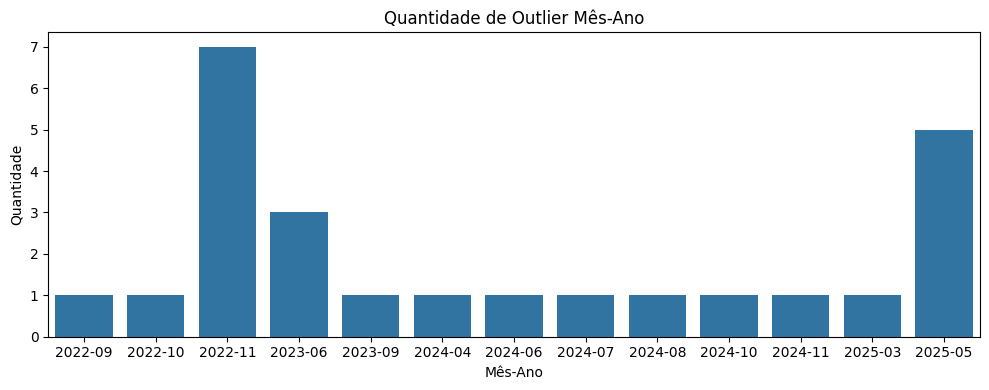

In [21]:
outlier_year_month = ts_outlier['year_month'].value_counts().reset_index()
outlier_year_month = outlier_year_month.sort_values('year_month')

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=outlier_year_month, x='year_month', y='count', ax=ax)
ax.set_title('Quantidade de Outlier Mês-Ano')
ax.set_ylabel('Quantidade')
ax.set_xlabel('Mês-Ano')

plt.tight_layout()
plt.show()


- A quantidade de outlier expressiva que aconteceu na Black de 2022 não se repetiu na Black de 2023 e nem 2024. A quantidade de outliers, basicamente está diminuindo e quando acontece temos uma ocorrência dentro do mês.

## Análise da Receita por Dia

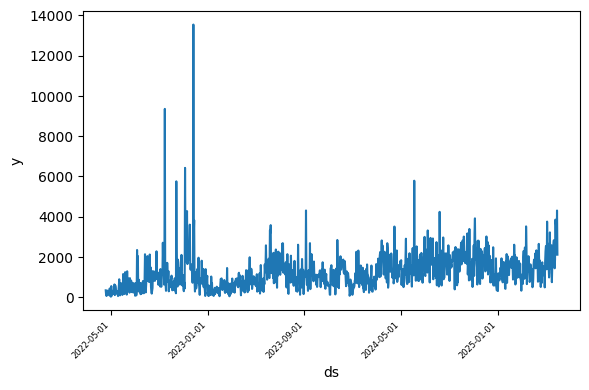

In [22]:
eda.line_over_period(period='ds')

- A princípio, não temos uma tendência clara nos dados de crescimento. Tem alguns destaques para os dados que são outliers.
- Para continuarmos as análises e testes estatísticos, vamos buscar transformar os dados para diminuir o efeito dos outliers

## Transformação dos Dados

- Vamos transformar os dados, visto que informações diárias tendem a ser mais voláteis do que as mensais

In [23]:
transforms = [np.log, np.sqrt, lambda x: np.power(x, 1/3), lambda x: np.power(x, 1/4)]

transforms_names = ["log", "raiz_quadrada", "raiz_cubica", "raiz_quarta"]

values = np.array(ts["y"])

for i, transform in enumerate(transforms):
    value_transform = transform(values)
    print(f"Assimetria encontrada no valor transformado: {stats.skew(value_transform)}\n")
    print(f"Nome da transformacao: {transforms_names[i]}")
    print(f"=========================================================")

Assimetria encontrada no valor transformado: -0.9900695118087502

Nome da transformacao: log
Assimetria encontrada no valor transformado: 0.5959304124170137

Nome da transformacao: raiz_quadrada
Assimetria encontrada no valor transformado: 0.024306917576457223

Nome da transformacao: raiz_cubica
Assimetria encontrada no valor transformado: -0.23219064185731716

Nome da transformacao: raiz_quarta


In [24]:
value_box, lmb = stats.boxcox(values)
print(f"Assimetria encontrada no valor transformado: {stats.skew(value_box)}\n")
print(f"Nome da transformacao: Box-Cox")

Assimetria encontrada no valor transformado: 0.05098013271098857

Nome da transformacao: Box-Cox


- A raiz cúbica apresentou melhor assimetria ao transformar os dados
- Vamos visualizar sua distribuição

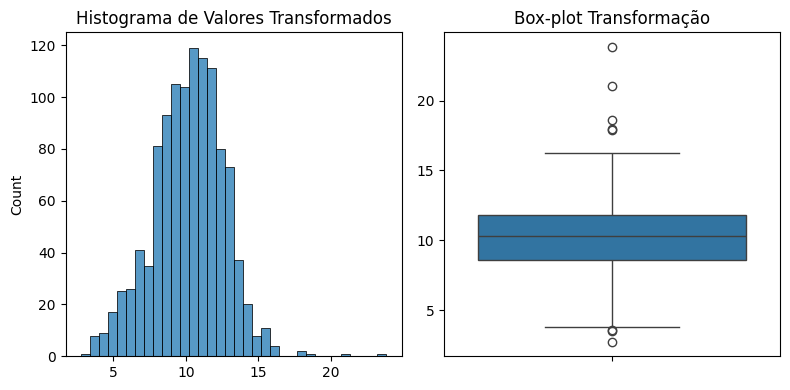

In [25]:
transf_raiz_cubica = np.power(values, 1/3)

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax = ax.flatten()
sns.histplot(transf_raiz_cubica, ax=ax[0])
ax[0].set_title("Histograma de Valores Transformados")

sns.boxplot(transf_raiz_cubica, ax=ax[1])
ax[1].set_title("Box-plot Transformação")

plt.tight_layout()
plt.show()


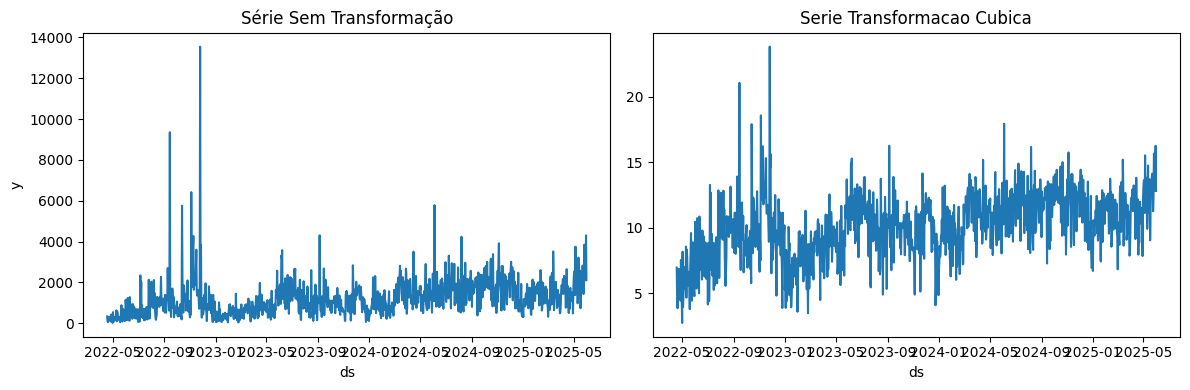

In [26]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax = ax.flatten()

sns.lineplot(x=ts['ds'], y=ts['y'], ax=ax[0])
ax[0].set_title("Série Sem Transformação")

sns.lineplot(x=ts['ds'], y=transf_raiz_cubica, ax=ax[1])
ax[1].set_title("Serie Transformacao Cubica")

plt.tight_layout()
plt.show()


## Buscando Encontrar Alguns Padrões

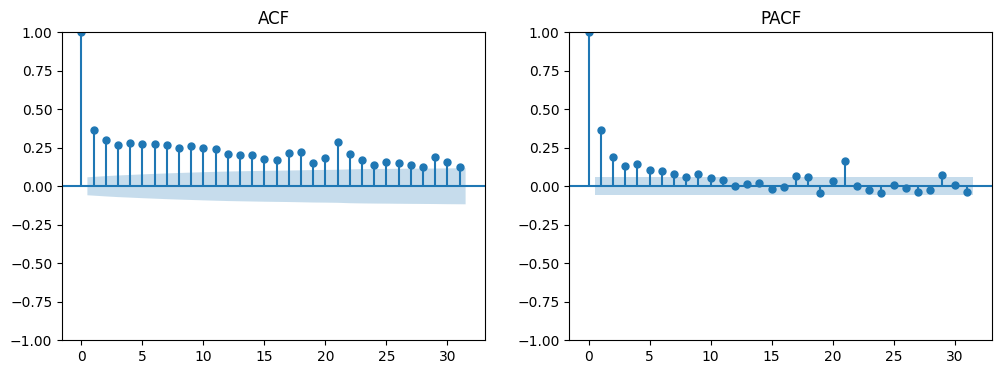

In [27]:
eda.plot_acf_pacf()

- De início, ainda parece que temos um modelo MA, visto que temos um declínio gradual no PACF. Contudo, não podemos afirmar isso visto que o ACF não cai para lags não significativos nas primeiras etapas.

- Além disso, não conseguimos perceber uma sazonalidade evidente nos nossos dados através dos lags.

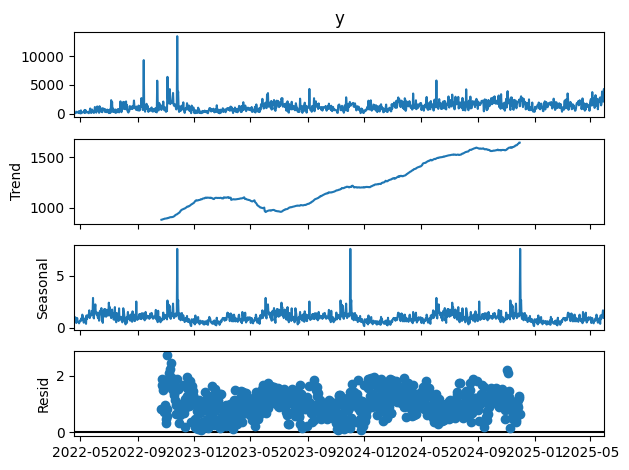

In [28]:
result = eda.decomposition_time_series(model='multiplicative', period=365)
result.plot();

- A princípio, temos uma decomposição que começa ficar com suas componentes mais aparente, com um período de 365, isto é, sugerindo uma sazonalidade anual.

- Vamos validar se o resíduo da série apresenta normalidade

In [29]:
residuos = result.resid.dropna().reset_index()
testes.test_normalidade(data=residuos["resid"])

'Aceitamos a hipótese nula com nível de significância: 0.05 e p_value: 0.0013123750942210038. Ou seja os dados não se distribuem normalmente'

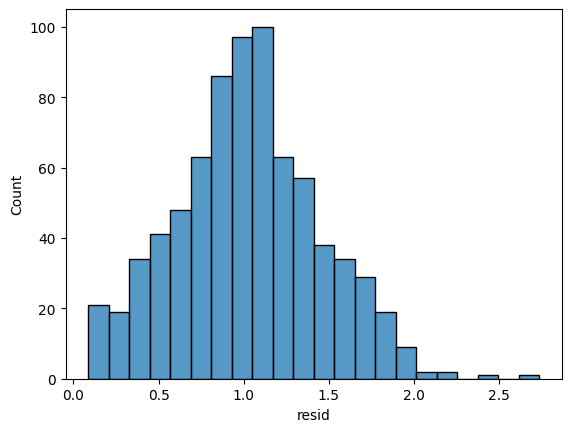

In [30]:
sns.histplot(residuos["resid"])
plt.show()

- Nós temos um resíduos que ainda não apresenta normalidade. Ou seja, ainda tem alguns pontos que a decomposição não conseguiu ajustar.

- Olhando para o histograma, percebe-se que o dado apresenta alguns valores com alto desvio padrão.

- Vamos analisar em quais dias isso aconteceu

In [31]:
residuos.loc[residuos['resid'] >= 2.0, :]

,ds,resid
13,2022-11-04,2.735143
17,2022-11-08,2.105837
18,2022-11-09,2.246850
20,2022-11-11,2.460610
736,2024-11-03,2.228021
737,2024-11-04,2.117071


- Basicamente os resíduos que estão mais afastados da média ocorreram no período de black. Além disso, a Black de 2022 contém o maior número de resíduos fora da média

## Análise de Tendência

In [32]:
testes.test_trend_linear_regression(data=transf_raiz_cubica)

Coeficiente angular: 0.003348641579034587
Possível tendência detectada


Componentes Detalhados Regressão Linear

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     278.3
Date:                Fri, 11 Jul 2025   Prob (F-statistic):           5.19e-56
Time:                        08:50:13   Log-Likelihood:                -2486.4
No. Observations:                1128   AIC:                             4977.
Df Residuals:                    1126   BIC:                             4987.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------

- Temos um valor do coeficiente para tendência bem baixo. Um dos motivos para isso pode ser devido a granularidade dos dados. Para uma análise mais a longo prazo seria interessante validarmos a tendência mensal.

- Além disso, o R2 apresentou um valor muito baixo, ou seja, a tendência linear não explica muito sobre a variabilidade dos nossos dados. 

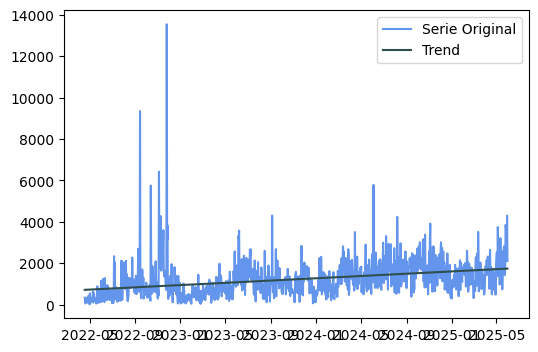

In [33]:
eda.trend_graph()

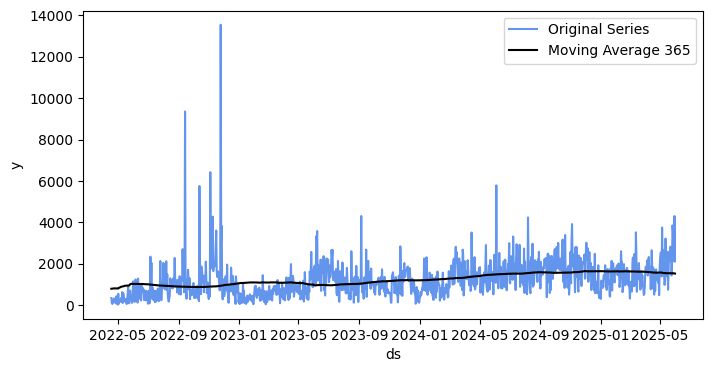

In [34]:
eda.moving_average_graph(len_window=365,
                        min_periodos=183)

## Padrões Sazonais

- Nessa etapa, buscaremos encontrar algum padrão sazonal que nos ajude a trazer mais informação quando formos modelarmos os nossos dados

### Padrão do dia da Semana

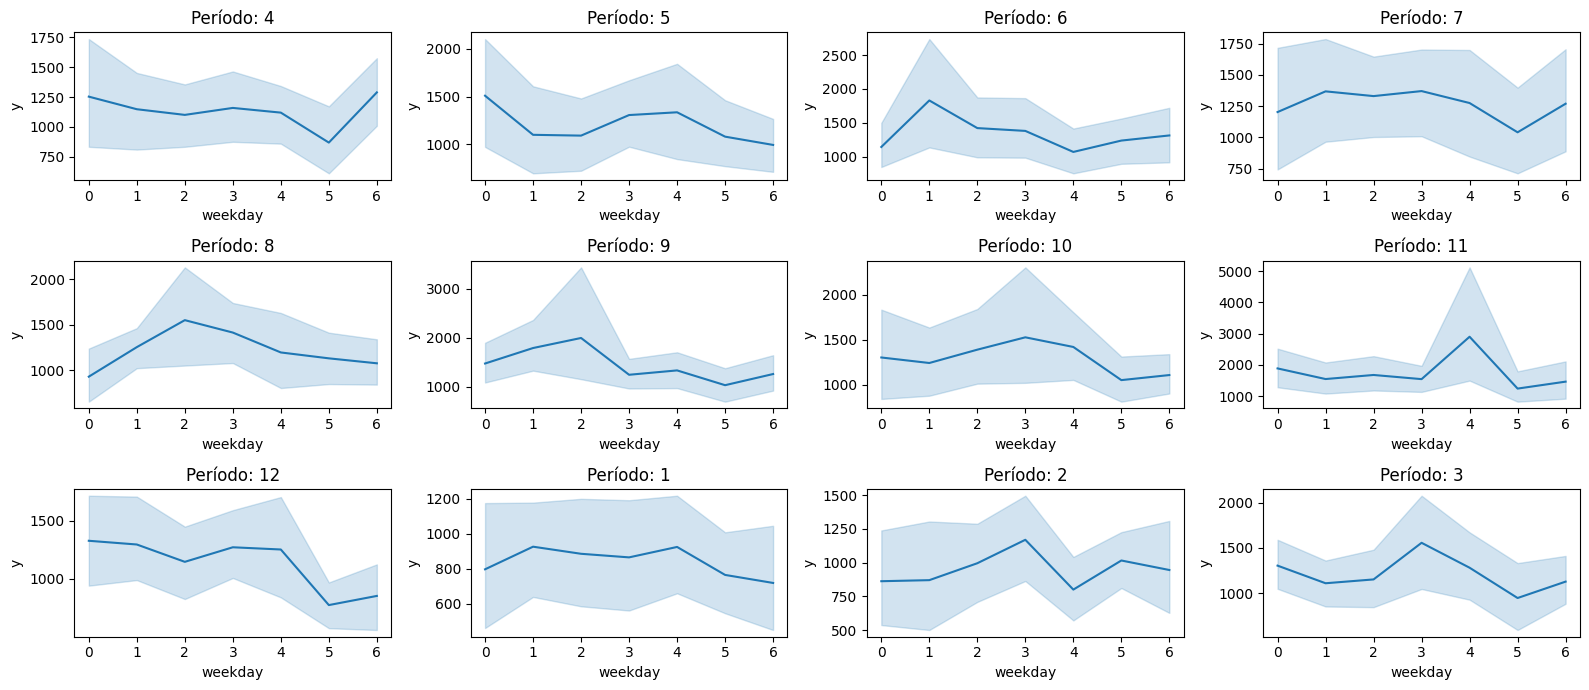

In [35]:
eda.line_subplots_period()

- A princípio não vemos uma sazonalidade muito bem definida de dia da semana. 
- Alguns meses tem pico na quinta, outros na sexta, já outros na quarta.

### Padrões Ano

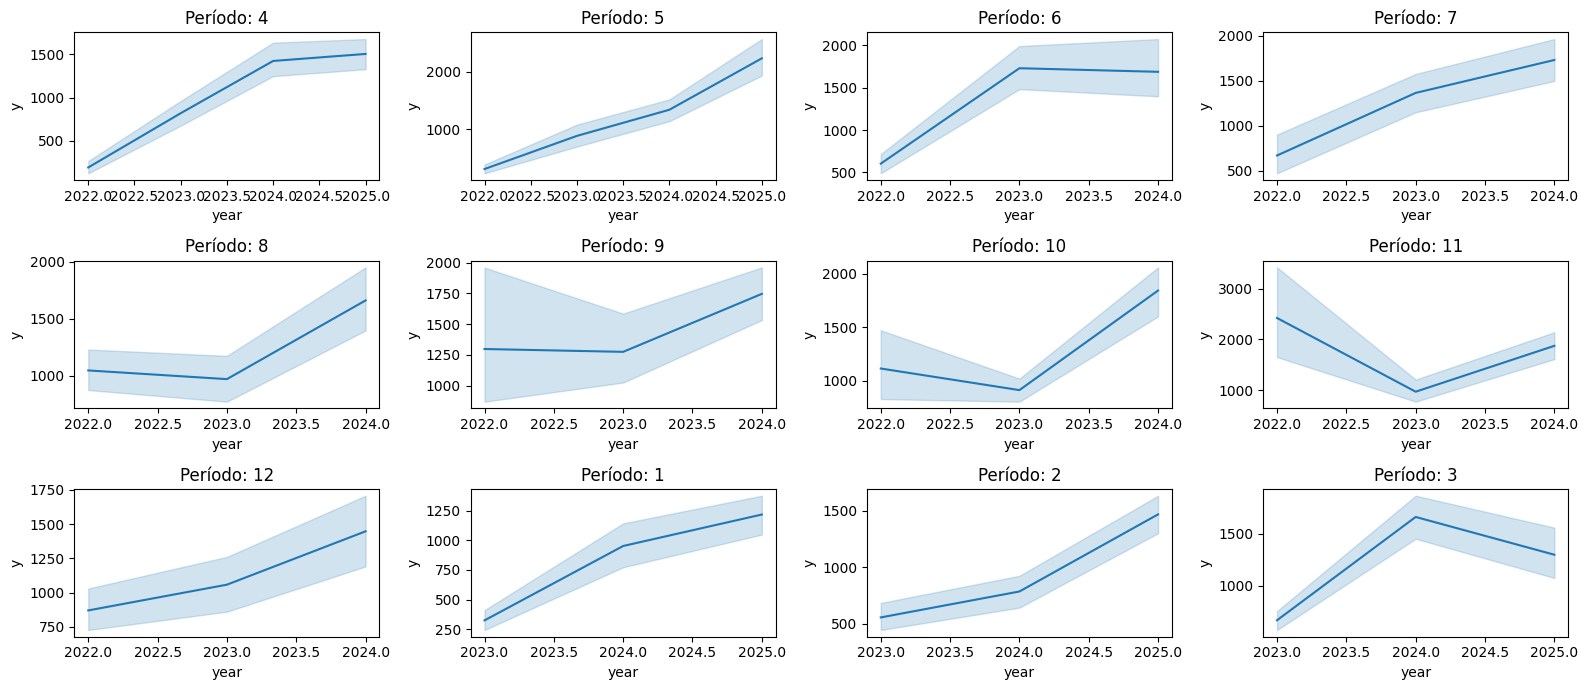

In [36]:
eda.line_subplots_period(period_sec="year")

- Alguns meses, como setembro, tem uma amplitude muito grande de receita. Mas no geral, essa amplitude vem diminuindo

### Padrão Dia do Mês

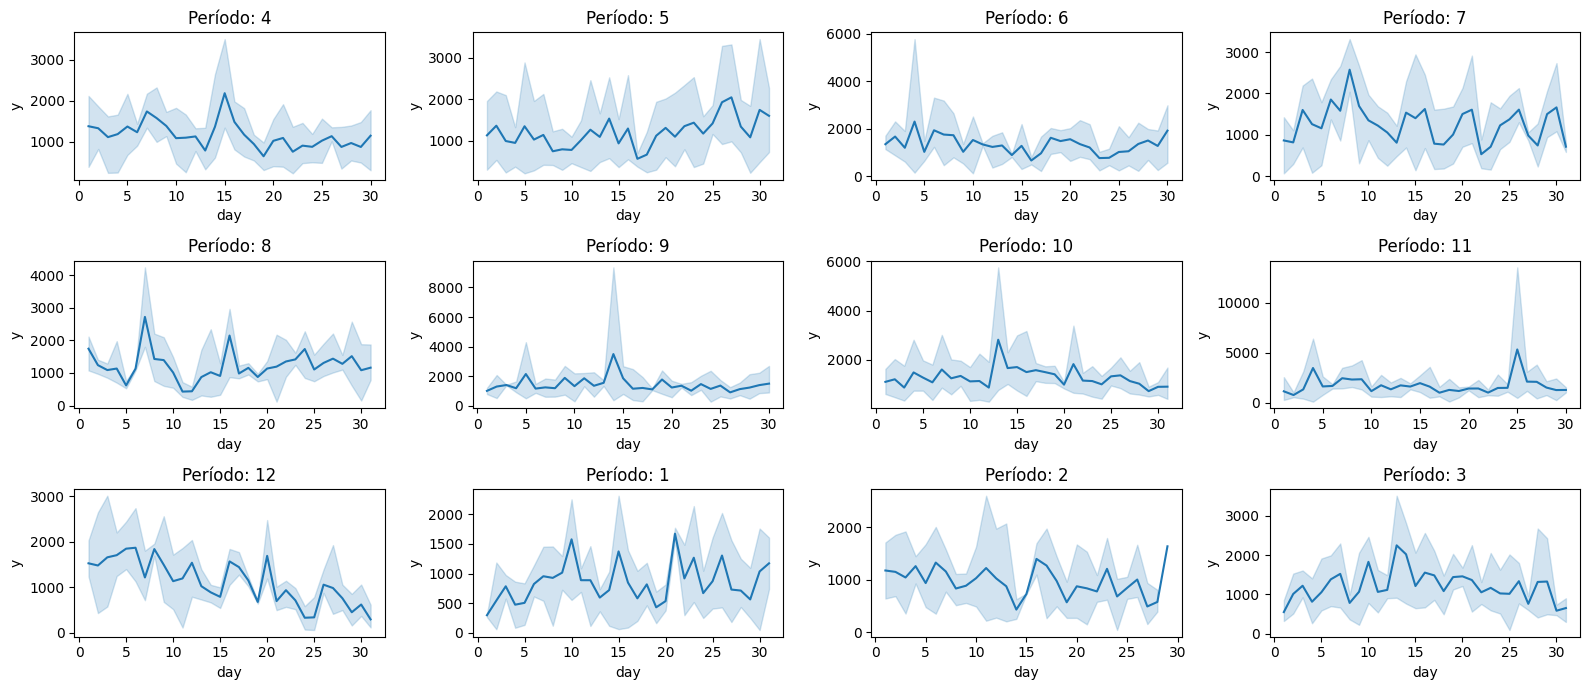

In [37]:
eda.line_subplots_period(period_sec="day")

- Alguns meses apresentam uma sazonalidade mais bem definida para a primeira quinzena. Por exemplo, dezembro, a segunda metade tem uma queda de faturamento.

- Já no mês 5 a segunda quinzena fica mais forte, principalmente devido ao dia dos namorados. Mês de agosto o início tem alguns picos, visto que temos o dia dos Pais. 

### Padrão Mês do Ano

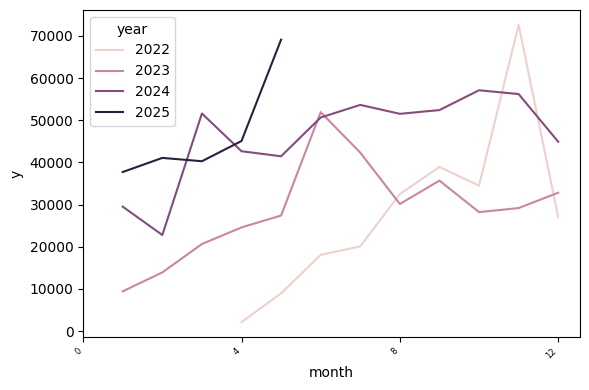

In [38]:
eda.line_over_period(hue="year")

- Novamente, não vemos uma sazonalidade muito clara entre os meses do ano;

- Por exemplo, os anos de 2022 e 2023 apresentou crescente entre mês 4 e 6. Porém, em 2023 nós começamos a ter uma queda depois do maior pico.

- Interessante que, sempre após um grande pico, nós temos uma queda relevante de receita que nem sempre volta para os mesmos padrões.
  
- Além disso, os picos em cada ano acontecem em períodos diferentes.

- Em 2022 temos em novembro, 2023 no mês 6, em 2024 no mês 3 e em 2025 no mês 5

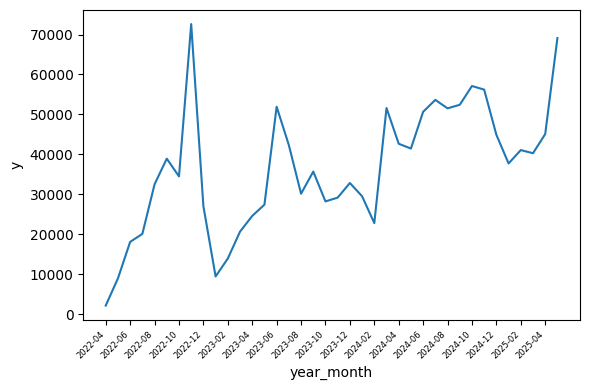

In [39]:
eda.line_over_period(period="year_month")

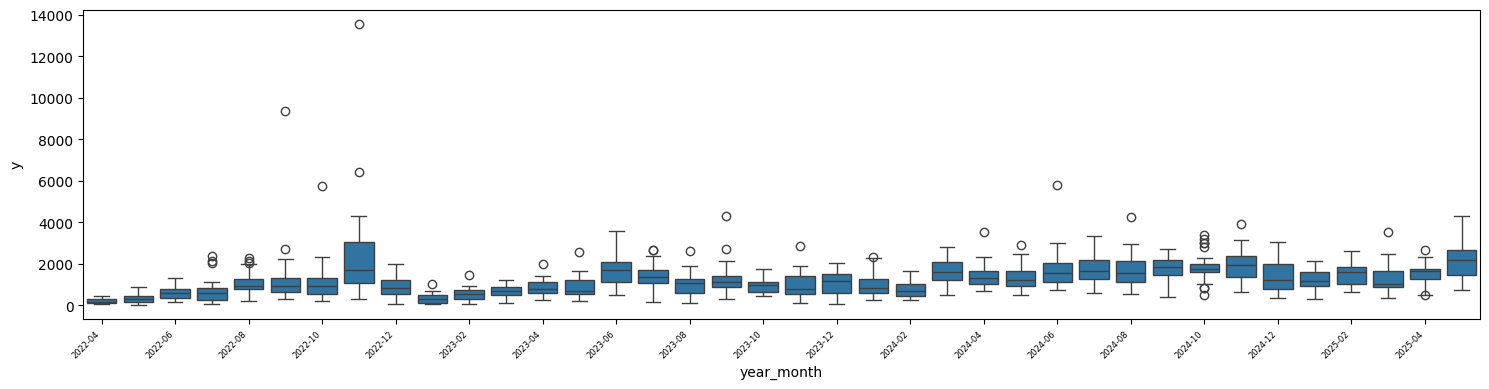

In [40]:
eda.box_plot_over_period(period="year_month")

### Testes de Sazonalidade

- Visto que fizemos uma análise de sazonalidade mais gráfica, partiremos para alguns testes estatísticos.
- Nós vamos remover a tendência da série temporal e fazer os testes para validar se há sazonalidade.
- Além disso, vamos trabalhar com os dados a partir de janeiro de 2023.
- Quando analisamos 2022 temos alguns dados bem ruidosos e que não aconteceu posteriormente, isso pode prejudicar a acurácia das análises

In [41]:
ts_2023 = ts.loc[ts["ds"] > "2022-12-31", :].copy()

Assimetria: 0.03487147920146886


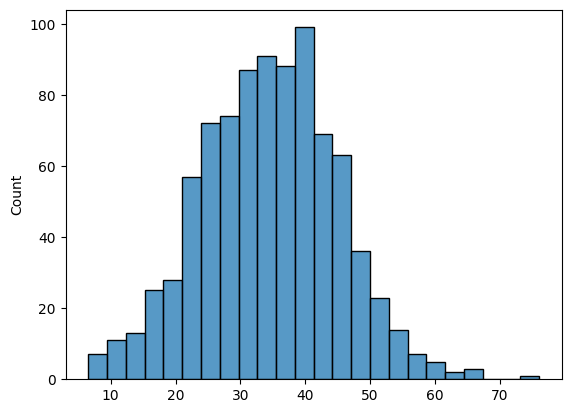

In [42]:
y_values = ts_2023["y"].values
sqrt_y = np.sqrt(y_values)

print(f'Assimetria: {stats.skew(sqrt_y)}')
sns.histplot(sqrt_y)
plt.show()

- Temos uma assimetria bem menor do que os dados originais o que, em tese, pode facilitar nossa modelagem

In [43]:
ts_2023['y_sqrt'] = sqrt_y
ts_2023.drop(columns=["y"], inplace=True)
ts_2023.rename(columns={"y_sqrt":"y"}, inplace=True)

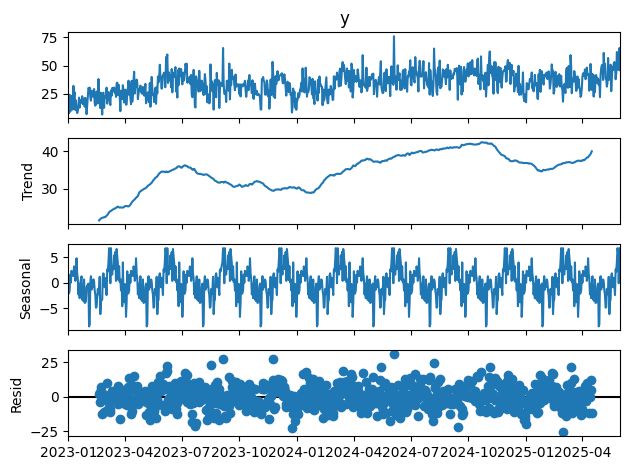

In [44]:
eda_sqrt = EdaTimeSeries(ts=ts_2023)

result = eda_sqrt.decomposition_time_series(model='aditive', period=90)
result.plot();

In [45]:
resid = result.resid.reset_index().dropna()

In [46]:
testes.test_normalidade(resid["resid"])

'Rejeitamos a hipótese nula com nível de significância: 0.05 e p_value: 0.1117084696982405. Ou seja os dados se distribuem normalmente'

In [47]:
testes.test_estacionariedade(resid["resid"])

Estatística do teste ADF: -7.461259427512637
P-value: 5.3464088031216636e-11
Número de Lags Usados: 6
Número de Observações Usadas 778
Valores Críticos
1%: -3.439
5%: -2.865
10%: -2.569
Série Considerada Estacionária


- Ou seja, a série depois de retiratada tendência e sazonalidade temos uma série estacionária. Um resíduo que não é correlacionado. 

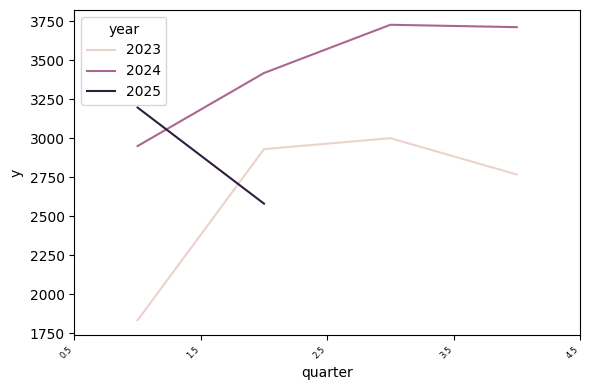

In [48]:
eda_sqrt.line_over_period(period="quarter", hue="year")

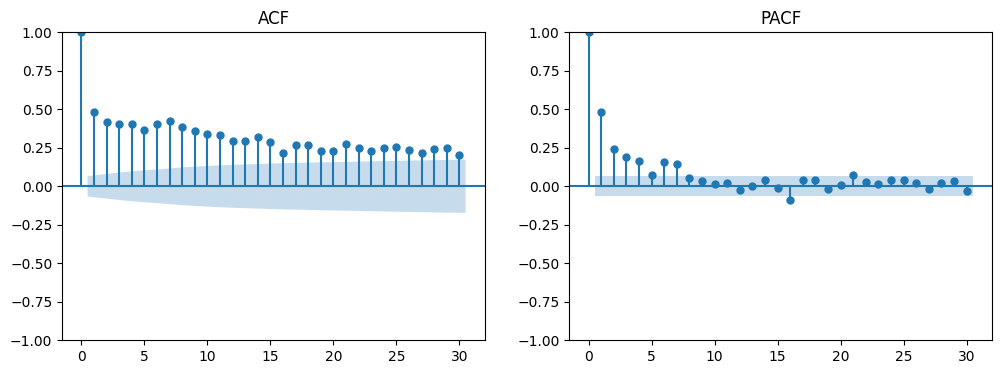

In [49]:
eda_sqrt.plot_acf_pacf()

In [50]:
seasonal = result.seasonal.reset_index()
seasonal.rename(columns={"seasonal":"y"}, inplace=True)

seasonal.insert(0, 'unique_id', 'ecommerce-sale')

seasonal = preprocess.preprocess(seasonal)

In [51]:
groups_semanal = [group["y"].values for _, group in seasonal.groupby("day")]

testes.teste_sazonalidade(grupos=groups_semanal)

'Aceitamos a hipótese nula com p_value: 8.247625440153343e-07 com nível de significância: 0.05. Há evidências de sazonalidade'

In [52]:
groups_trimestral = [group["y"].values for _, group in seasonal.groupby("quarter")]

testes.teste_sazonalidade(grupos=groups_trimestral)

'Não rejeitamos a hipóteste nula com p_value de 0.9921475228693599 com nível de significância: 0.05. Não há evidências de sazonalidade'

In [53]:
groups_month = [group["y"].values for _, group in seasonal.groupby("month")]

testes.teste_sazonalidade(grupos=groups_month)

'Aceitamos a hipótese nula com p_value: 8.77597819328778e-16 com nível de significância: 0.05. Há evidências de sazonalidade'

- Pelos testes estatísticos de Kruskal-Wallis nós temos sazonalidade semanal e uma mensal na nossa série.

- Agora o objetivo é buscar entender como lags e outras features numéricas ajuda a explicar o resultado

## Feature Engineering

### Lag Features

In [54]:
ts_2023.reset_index(drop=True, inplace=True)

In [55]:
preprocess_lags = MLForecast(
    models=[],
    freq=['D'],
    lags=[1, 2, 3, 4, 5, 6, 7, 14, 21, 28, 90],
    lag_transforms={
        1: [RollingMean(window_size=3), RollingMean(window_size=7), RollingMean(window_size=14),
            RollingMax(window_size=7), RollingMax(window_size=14),
            SeasonalRollingMean(season_length=7, window_size=2)],
        7: [RollingMean(window_size=7), RollingMean(window_size=14)],
        14: [RollingMax(window_size=21), RollingMax(window_size=28)]
    }
)

ts_2023_lag = preprocess_lags.preprocess(ts_2023, static_features=[])

In [56]:
#selecao das colunas para validar correlacao

df_numeric = ts_2023_lag.select_dtypes(include=["float"])
corr_matrix = df_numeric.corr()
corr_matrix["y"].sort_values(ascending=False)

y                                                         1.000000
rolling_mean_lag1_window_size7                            0.492280
rolling_mean_lag1_window_size14                           0.464722
rolling_mean_lag1_window_size3                            0.439406
seasonal_rolling_mean_lag1_season_length7_window_size2    0.419255
lag1                                                      0.391526
rolling_mean_lag7_window_size7                            0.384770
rolling_max_lag1_window_size7                             0.377443
rolling_mean_lag7_window_size14                           0.348496
rolling_max_lag1_window_size14                            0.344476
lag7                                                      0.341206
lag6                                                      0.321843
lag2                                                      0.308981
lag4                                                      0.306634
lag3                                                      0.30

### Criação de Features Promocionais

In [57]:
#criando as features de datas promocionais
dates_black_2023 = create_list_dates(date_initial="2023-11-06", qtd_dias=25)
black_friday = create_promo(period_list=dates_black_2023, promo_name="black", data={})

dates_black_2024 = create_list_dates(date_initial="2024-11-06", qtd_dias=25)
black_friday = create_promo(period_list=dates_black_2024, promo_name="black", data=black_friday)
df_black = pd.DataFrame(black_friday)

#super_sale
dates_super_sale_2023 = create_list_dates(date_initial="2023-07-07", qtd_dias=7)
super_sale = create_promo(period_list=dates_super_sale_2023, promo_name="super_sale", data={})
df_ss = pd.DataFrame(super_sale)

#aniversario
dates_aniversario_24 = create_list_dates(date_initial="2024-06-04", qtd_dias=1)
aniversario = create_promo(period_list=dates_aniversario_24, promo_name="aniversario", data={})
df_ani = pd.DataFrame(aniversario)

#black fora de epoca

dates_black_fe_24 = create_list_dates(date_initial="2024-08-10", qtd_dias=22)
black_fe = create_promo(period_list=dates_black_fe_24, promo_name="black_fe", data={})
df_bfe = pd.DataFrame(black_fe)

#maes 

dates_maes_25 = create_list_dates(date_initial="2025-04-14", qtd_dias=28)
maes = create_promo(period_list=dates_maes_25, promo_name="maes", data={})
df_mae = pd.DataFrame(maes)

#namorados 
dates_namorados_25 = create_list_dates(date_initial="2025-05-20", qtd_dias=24)
namorados = create_promo(period_list=dates_namorados_25, promo_name="namorados", data={})
df_nam = pd.DataFrame(namorados)


- apos criado as features promocionais, vamos agregá-las ao nosso dataframe

In [58]:
ts_2023_promo = ts_2023.copy()

ts_2023_promo = ts_2023_promo.merge(df_black,
                                    on="ds",
                                    how="left")

ts_2023_promo = ts_2023_promo.merge(df_ss,
                                    on="ds",
                                    how="left")

ts_2023_promo = ts_2023_promo.merge(df_ani,
                                   on="ds",
                                   how="left")

ts_2023_promo = ts_2023_promo.merge(df_bfe,
                                    on="ds",
                                    how="left")

ts_2023_promo = ts_2023_promo.merge(df_mae,
                                    on="ds",
                                    how="left")

ts_2023_promo = ts_2023_promo.merge(df_nam,
                                    on="ds",
                                   how="left")

In [59]:
ts_2023_promo.fillna(False, inplace=True)

/tmp/ipykernel_67/1870202977.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ts_2023_promo.fillna(False, inplace=True)


In [60]:
ts_2023_promo.head()

,unique_id,ds,day,year,month,weekday,year_month,quarter,y,black,super_sale,aniversario,black_fe,maes,namorados
0,ecommerce-sale,2023-01-01,1,2023,1,6,2023-01,1,16.295091,False,False,False,False,False,False
1,ecommerce-sale,2023-01-02,2,2023,1,0,2023-01,1,7.712328,False,False,False,False,False,False
2,ecommerce-sale,2023-01-03,3,2023,1,1,2023-01,1,24.030189,False,False,False,False,False,False
3,ecommerce-sale,2023-01-04,4,2023,1,2,2023-01,1,9.214120,False,False,False,False,False,False
4,ecommerce-sale,2023-01-05,5,2023,1,3,2023-01,1,11.552056,False,False,False,False,False,False


## Teste Para Relevância de Features

In [85]:
#vamos pegar apenas os lags mais correlacionados para fazermos os testes

preprocess_lags = MLForecast(
    models=[],
    freq=['D'],
    lags=[1, 7],
    lag_transforms={
        1: [RollingMean(window_size=3), RollingMean(window_size=7), RollingMean(window_size=14),
            SeasonalRollingMean(season_length=7, window_size=2)]
    }
)

ts_2023_fs = preprocess_lags.preprocess(ts_2023_promo, static_features=[])

In [86]:
ts_2023_fs.reset_index(drop=True, inplace=True)

In [87]:
#verificar o shape do nosso dado 

ts_2023_fs.shape

(861, 21)

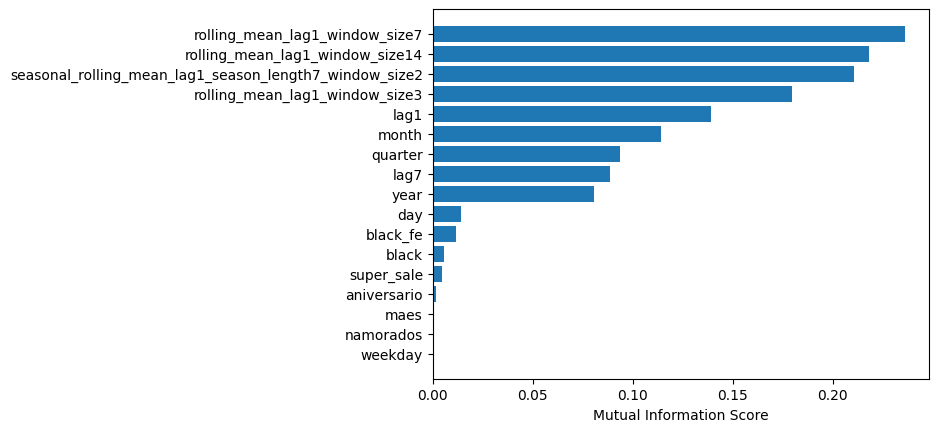

In [104]:
#divisao target e predictor

data = ts_2023_fs.drop(["y", "unique_id", "ds", "year_month"], axis="columns")
target = ts_2023_fs.y

#divisao treino e teste 

data_train, data_test, target_train, target_test = train_test_split(data, target, train_size=.75, shuffle=False, random_state=42)

#validacao da mutual information 
mi_score = mutual_info_regression(
    data_train,
    target_train
)

#visualizacao 

sorted_idx = np.argsort(mi_score)
mi_scoredf = pd.DataFrame(
    mi_score[sorted_idx[::-1]],
    index=data_train.columns[sorted_idx[::-1]],
    columns=["mi_score"]
)

plt.barh(
    data_train.columns[sorted_idx],
    mi_score[sorted_idx])

plt.xlabel("Mutual Information Score")
plt.show()

## Análise Receita por Mês

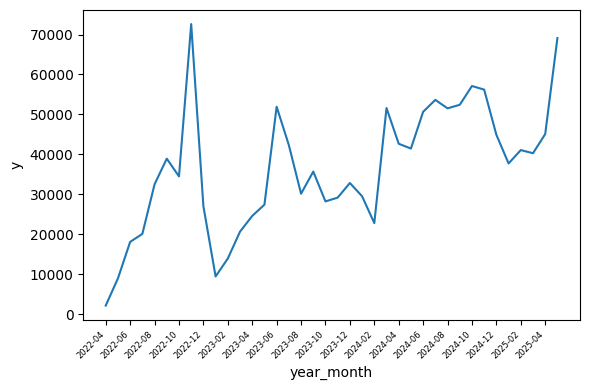

In [61]:
ts_month = ts.groupby(['year_month', 'month', 'year'])['y'].sum().reset_index()
eda_month = EdaTimeSeries(ts=ts_month)
eda_month.line_over_period(period='year_month')


- Analisando mensalmente, com os dados agregados para reduzir a variância, percebe-se um claro crescimento de abril até novembro. Depois uma queda. Novamente tivemos uma escalada até o mês 6 em 2023 e queda seguida de um platô na receita. Em 2024 começou o ano em baixa e novamente melhoramos os resultados, porém em janeiro de 2025 tivemos novamente uma queda.

- Aparentemente, quando temos um pico, sempre vem um momento de baixa

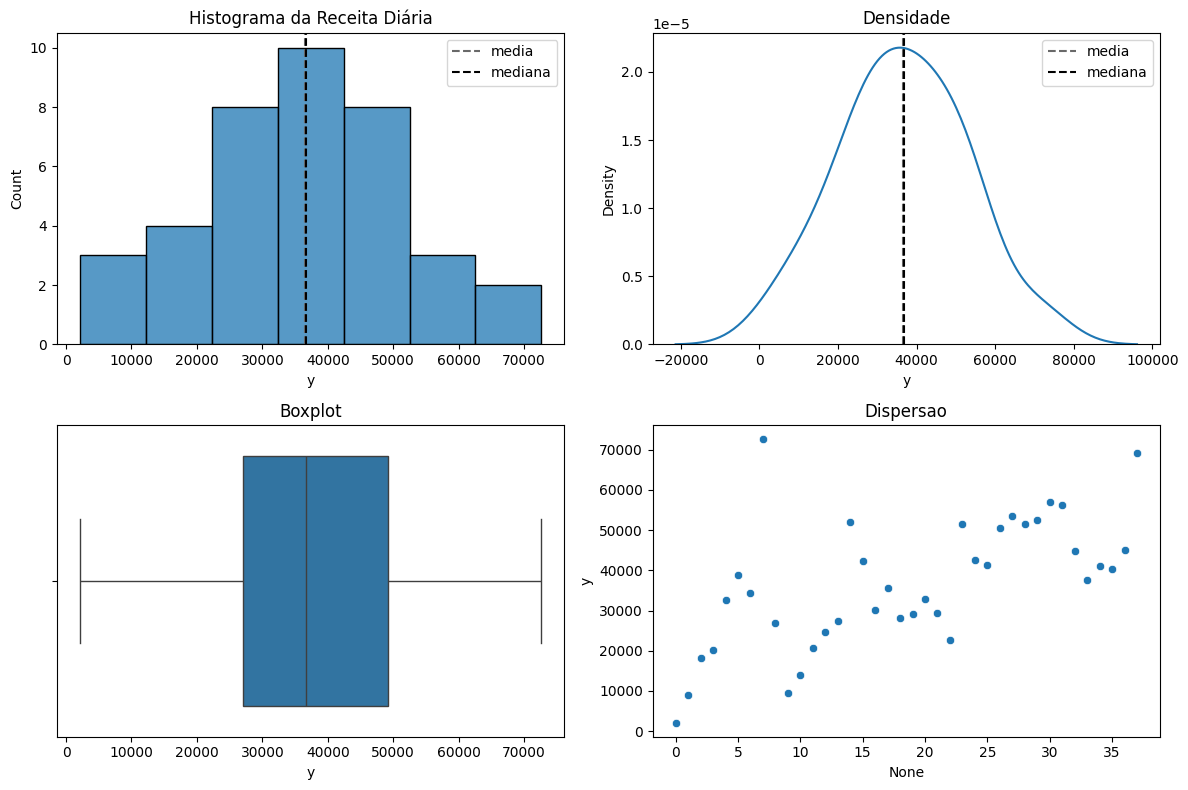

In [62]:
eda_month.univariate_hist_box()

- Sendo a receita mensal, percebe-se que os dados se aproximam bem de uma curva normal, tanto que a média e mediana estão plotadas uma sobre a outra

In [63]:
mu = ts_month['y'].mean()
md = ts_month['y'].median()

print(f'Valor da média é: {mu} e mediana de {md}')

Valor da média é: 36541.93657894737 e mediana de 36700.16499999999


In [64]:
stats.skew(ts_month['y'])

np.float64(0.03998202244178941)

- Pela métrica temos um dado quase simétrico